# Métodos matemáticos

# (a quick) Introduction to numerical methods in scientific computing

# Interpolation

Interpolation is a method of estimating values between two known data points. It's commonly used to approximate a function based on a limited number of discrete data points.  There are several interpolation methods, but we'll focus on three popular ones: linear interpolation, polynomial interpolation (specifically, Lagrange interpolation), and spline interpolation (cubic splines).


## Linear interpolation

Linear interpolation estimates values between two adjacent data points using a straight line.

### One-dimensional linear interpolation

Given two data points $(x_1, y_1)$ and $(x_2, y_2)$, the linearly interpolated value ($y$) at some point $x$ within the range $[x1, x2]$ is calculated as:

$$y = y_1 + \frac{y_2 - y_1}{x_2 - x_1}(x - x_1) $$

Linear interpolation can be performed using the `scipy.interpolate.interp1d` function from the SciPy library in Python

In [1]:
import numpy as np
from scipy.interpolate import interp1d

In [2]:
# Define the known data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 4, 9, 8])

# Create a linear interpolation function
linear_interp = interp1d(x, y, kind='linear')

# Now you can use the liner_interp function to interpolate data within the defined ranges
x_2 = 4.5
y_1 = linear_interp(x_2)

# would this function work if we try to interpolate outside the interpolation range?

### N-dimensional interpolation

Interpolating in n-dimensional space is a common task in scientific computing and data analysis. The `scipy.interpolate.griddata` function from the SciPy library in Python can be used for n-dimensional interpolation. This function performs interpolation on scattered data points in n-dimensional space and returns a regular grid containing the interpolated data.

In [3]:
from scipy.interpolate import griddata

# Create sample data points in 2D (you can extend this to n dimensions)
x = np.random.rand(100)
y = np.random.rand(100)
alpha = np.random.rand(100)
z = x+y

# Define a grid on which to interpolate
xi, yi, alphai = np.mgrid[0:1:100j, 0:1:100j,0:1:200j]

# Perform n-dimensional interpolation using griddata
zi = griddata((x, y,alpha), z, (xi, yi,alphai), method='linear')

- Plot the original and interpolated data in a 2D plot using the `matplotlib.pyplot.contourf` function
- Explore the other interpolation methods available in the griddata function

The LinearNDInterpolator can be used for n-dimensional interpolation using linear interpolation. This method is particularly useful when you have data scattered in n-dimensional space and you want to approximate values at non-grid locations.

In [4]:
from scipy.interpolate import LinearNDInterpolator

# Create sample data points in 2D (you can extend this to n dimensions)
x = np.random.rand(100)
y = np.random.rand(100)
z = np.sin(x * y)

# Define the points at which you want to interpolate
points_to_interpolate = np.random.rand(20, 2)  # 20 points in 2D space

# Create a LinearNDInterpolator
interpolator = LinearNDInterpolator((x, y), z)

# Perform interpolation at the specified points
interpolated_values = interpolator(points_to_interpolate)

- Compare the <b>LinearNDInterpolator</b> and <b>griddata</b> functions. When do you think each one would be useful to employ?

## Polinomial interpolation

Polynomial interpolation is a method used to approximate a function by fitting a polynomial through a set of data points. Common forms of polynomial interpolation are the <b>Lagrange form</b>, the <b>Newton form</b>, <b>Pade approximation</b> and the <b>Taylor polynomial</b>. All methods aim to find a polynomial that passes through a given set of points.

### Lagrange Polynomial Interpolation

The Lagrange polynomial interpolation constructs a polynomial by creating individual basis polynomials for each data point and then combining them. Given a set of data points $(x_i, y_i)$ for $i = 0, 1, 2, \ldots, n$, the Lagrange polynomial $P(x)$ can be expressed as:

$$
P(x) = L_0(x) \cdot y_0 + L_1(x) \cdot y_1 + \ldots + L_n(x) \cdot y_n
$$

Where $L_i(x)$ is the Lagrange basis polynomial for each point $i$:

$$
L_i(x) = \frac{{(x - x_0)(x - x_1) \ldots (x - x_{i-1})(x - x_{i+1}) \ldots (x - x_n)}}{{(x_i - x_0)(x_i - x_1) \ldots (x_i - x_{i-1})(x_i - x_{i+1}) \ldots (x_i - x_n)}}
$$


In [5]:
from scipy.interpolate import lagrange

# Define data points (x and y)
x = [1, 2, 3, 4, 5]
y = [5, 7, 4, 9, 8]

# Create a Lagrange polynomial interpolant
lagrange_polynomial = lagrange(x, y)

# Evaluate the interpolant at a specific point
x_interp = 2.5
y_interp = lagrange_polynomial(x_interp)


- Explore the difference between Lagrange, Newton, Pade and Taylor interpolation. Whe should you use each one?
- Investigate about existing implementations of these interpolation methods in SciPy

## Cubic spline interpolation

**Cubic spline interpolation** is a widely used method for approximating a smooth curve that passes through a given set of data points. Unlike polynomial interpolation, which uses a single polynomial to approximate the entire dataset, cubic spline interpolation divides the data into smaller segments and fits a cubic polynomial to each segment. This results in a piecewise continuous and smooth curve.

Cubic spline interpolation is advantageous because it provides a smooth and continuous curve that passes through the data points. It is often used in applications where preserving the shape of the data is crucial, such as in computer graphics, engineering, and scientific data analysis.



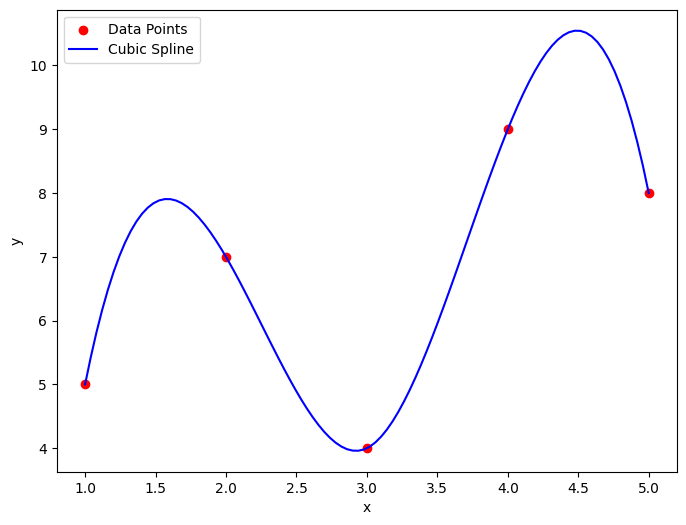

In [6]:
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define data points
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 4, 9, 8])

# Create a cubic spline interpolant
cs = CubicSpline(x, y)

# Generate points for the interpolated curve
x_interp = np.linspace(1, 5, 100)
y_interp = cs(x_interp)

# Plot the original data and the interpolated curve
plt.figure(figsize=(8, 6))
plt.scatter(x, y, label='Data Points', color='red')
plt.plot(x_interp, y_interp, label='Cubic Spline', color='blue')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

- In a same graphic, plot curves generated using the different interpolation methods described above. What's the difference between them?

# Curve fitting

<b>Curve fitting</b> is the process of finding a mathematical function that best represents a set of data points. The `scipy.optimize.curve_fit` function in SciPy is commonly used for this purpose. It fits a user-defined function to the data and returns the parameters of the function that best describe the data.

In [7]:
from scipy.optimize import curve_fit

# Define the function to fit (e.g., a Gaussian function)
def func(x, a, b, c):
    return a * np.exp(-(x - b)**2 / (2 * c**2))

# Generate synthetic data with noise
x_data = np.linspace(0, 10, 100)
y_data = func(x_data, 2.5, 5, 1.2) + 0.2 * np.random.normal(size=len(x_data))

# Perform curve fitting
params, covariance = curve_fit(func, x_data, y_data, p0=[1, 1, 1])

# Extract the fitted parameters
a_fit, b_fit, c_fit = params

- Create a plot including the original points and the fitted curve
- Investigate about fitting errors. How can we estimate the error associated to each computed parameter?
- Investigate about the initial guesses. Does the curve_fit function use a default value if not included as arguments?
- Can the curve_fit function fit a multi dimensional function?

## Polynomial curve fitting

Curve fitting to polynomials of different degreees can be achieved using the  `numpy.polyfit` function. It fits a polynomial of a specified degree to a set of data points, minimizing the least-squares error.

In [8]:
# Define data points (x and y)
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 7, 4, 9, 8])

# Define the degree of the polynomial you want to fit (e.g., degree=2 for a quadratic)
degree = 2

# Fit a polynomial of the specified degree to the data
coefficients = np.polyfit(x, y, degree)

# Create a polynomial function based on the coefficients
poly_function = np.poly1d(coefficients)

- Create a plot including the original points and the fitted curve
- Compare the results of fitting a curve to a polynomial using the numpy.polyfit and scipy.optimize.curve_fit functions

# Numerical integration

Numerical integration, also known as numerical quadrature, is a technique used to approximate the definite integral of a function when an analytical solution is difficult or impossible to obtain. There are various methods for numerical integration, including the trapezoidal rule, Simpson's rule, and more advanced techniques like Gaussian quadrature.

## Trapezoidal Rule

The trapezoidal rule approximates the integral of a function $f(x)$ over a closed interval $[a, b]$ by dividing the interval into $n$ subintervals and approximating each subinterval as a trapezoid. The formula for the trapezoidal rule is:

$$
\int_{a}^{b} f(x) \, dx \approx \frac{h}{2} \left[ f(a) + 2f(x_1) + 2f(x_2) + \ldots + 2f(x_{n-1}) + f(b) \right]
$$

Where $h = \frac{b - a}{n}$ is the width of each subinterval, and $x_i = a + ih$ for $i = 0, 1, 2, \ldots, n$.

## Simpson's Rule

Simpson's rule is a more accurate method that approximates the integral using quadratic polynomials over each pair of subintervals. The formula for Simpson's rule is:

$$
\int_{a}^{b} f(x) \, dx \approx \frac{h}{3} \left[ f(a) + 4f(x_1) + 2f(x_2) + 4f(x_3) + \ldots + 2f(x_{n-2}) + 4f(x_{n-1}) + f(b) \right]
$$

Where $h = \frac{b - a}{n}$, $x_i = a + ih$ for $i = 0, 1, 2, \ldots, n$, and $n$ is an even number.



## Numerical Integration in Python

Here's an example using the trapezoidal rule and Simpson's rule:



In [9]:
from scipy.integrate import trapezoid, simpson, quad

# Define the function to be integrated
f = lambda x: x**2

def f(x):
    return x**2

# Define the integration interval
a = 0
b = 2

# Create an array of x values
x = np.linspace(a, b, 100)

# Calculate the function values
y = f(x)

# Trapezoidal Rule
trapezoidal_integral = trapezoid(y, x)
# Simpson's Rule
simpson_integral = simpson(y, x)
# scipy generic integrator
quad_integral, error = quad(f,a,b)
print(quad_integral,trapezoidal_integral,simpson_integral)

2.666666666666667 2.6668027072067484 2.6666666666666665


- Compute the integral of the function:
$$f(x) = \sin(x) + e^{-x}$$ between $x=0$ and $x=1$. Analyze how the number of points affects the computed result

## Multidimensional integration


### Double Integral of a Function

Let's say you want to calculate the double integral of a function $f(x, y)$ over a specified region $\Omega$, which is defined by limits for both $x$ and $y$:

$$
\int_{\Omega} f(x, y) \, dx \, dy
$$



Multidimensional integration in Python can be performed using the `scipy.integrate` module, which provides various functions for integrating functions of multiple variables over specified domains.

In [10]:
from scipy.integrate import dblquad

# Define the function to be integrated
def f(x, y):
    return x**2 + y**2

# Define the integration limits for x and y
x_lower = 0
x_upper = 2
y_lower = 0
y_upper = 1

# Perform the double integral
result, error = dblquad(f, x_lower, x_upper, y_lower, y_upper)

### Triple Integral of a Function

To perform a triple integral in Python, you can use the `scipy.integrate.tplquad` function from the SciPy library.

Let's say you want to calculate the triple integral of a function $f(x, y, z)$ over a specified region $\Omega$, which is defined by limits for $x$, $y$, and $z$:

$$
\int_{\Omega} f(x, y, z) \, dx \, dy \, dz
$$



In [11]:
from scipy.integrate import tplquad

# Define the function to be integrated
def f(x, y, z):
    return x**2 + y**2 + z**2

# Define the integration limits for x, y, and z
x_lower = 0
x_upper = 1
y_lower = 0
y_upper = 1
z_lower = 0
z_upper = 1

# Perform the triple integral
result, error = tplquad(f, x_lower, x_upper, y_lower, y_upper, z_lower, z_upper)

#  Numerical Solutions to Non-Linear Systems of Equations

Numerical solutions to non-linear systems of equations are essential in various fields, including physics, engineering, economics, and optimization problems. In this context, a system of non-linear equations typically takes the form:


\begin{align*}
f_1(x_1, x_2, \ldots, x_n) &= 0 \\
f_2(x_1, x_2, \ldots, x_n) &= 0 \\
&\vdots \\
f_n(x_1, x_2, \ldots, x_n) &= 0 \\
\end{align*}


Where $n$ represents the number of equations and $x_1, x_2, \ldots, x_n$ are the variables you want to solve for.

Here are common numerical methods to find solutions to such systems:

## Newton-Raphson Method:

The Newton-Raphson method is an iterative technique used to find approximate solutions to non-linear systems. It starts with an initial guess and refines the solution in each iteration. For a system of equations, the method involves constructing a Jacobian matrix and solving a linear system in each step.

## Broyden's Method:

Broyden's method is a quasi-Newton method for solving non-linear systems of equations. It's similar to the Newton-Raphson method but doesn't require the computation of a full Jacobian matrix in each iteration. Instead, it approximates the Jacobian using updates based on function evaluations.

## Levenberg-Marquardt Algorithm:

The Levenberg-Marquardt algorithm is commonly used for solving non-linear least squares problems, which are a special case of non-linear systems of equations. It's efficient for problems involving optimization and curve fitting.

## Fixed-Point Iteration:

In some cases, you can convert a system of equations into a fixed-point iteration form \(x = g(x)\), where \(g(x)\) is a suitable function. Fixed-point iteration methods like the Jacobi or Gauss-Seidel method can be used to approximate solutions.

## Root-Finding Algorithms:

You can use root-finding algorithms like the bisection method, secant method, or the scipy.optimize.root function in Python to find solutions to individual equations in the system. Combining these methods can help solve the entire system.

## Optimization Algorithms

In many practical cases, solving a system of equations is equivalent to finding the minimum or maximum of an objective function. Optimization algorithms like gradient descent, conjugate gradient, or the BFGS method can be employed.

Here's an example of solving a simple non-linear system using the Newton-Raphson method in Python:


In [12]:
from scipy.optimize import newton

# Define the system of equations
def equations(x):
    x1, x2 = x
    f1 = x1 + x2**2 - 4
    f2 = x1*x2 - 2

    return [f1, f2]

# Initial guess
x0 = [1, 1]

# Solve the system using Newton-Raphson
solution = newton(equations, x0)

RuntimeError: all failed to converge after 50 iterations

- Does the presented example have solutions? (Plotting these functions can provide some insights)

Here's an example of solving a simple non-linear system using the `scipy.root` function:

In [13]:
from scipy.optimize import root

# Define the system of equations as a function
def equations(x):
    f1 = x[0] + x[1]**2 - 4
    f2 = x[0]*x[1] - 2
    return [f1, f2]

# Initial guess for the solution
x0 = [1, 1]

# Use scipy.optimize.root to find the root
result = root(equations, x0)
xres, yres = result.x
print(xres, yres)

1.1939365664752002 1.6751308705666559


- Compare the functions presented above. What is the difference between them?
- Investigate what is the default method of the `scipy.root` functions. What other methods can be employed? When should you use each?
- Why did the root function provides a result, but the newton one doesnt?
- How can you extend these examples to single non-linear equations and systems of equations of higher order?

# Test what you have learned


Consider the following system of non-linear equations:

$$
\begin{align*}
2x^2 + y^2 &= 10 \\
x^2 + 3y^2 &= 12 \\
\end{align*}
$$

- Find the solutions to this system of equations.

- Provide the values of $x$ and $y$ that satisfy both equations. If there are multiple solutions, list all of them.


# Challenge: Non-Linear Optimization Problem

In this challenge, you'll apply the concepts explored in this class, including numerical solutions to non-linear systems of equations and optimization techniques. Your task is to solve a non-linear optimization problem.

Consider the following non-linear optimization problem:

Minimize the objective function:

$$
f(x) = x_1^2 + 2x_2^2 - 2x_1x_2 - 4x_1
$$

Subject to the constraints:


\begin{align*}
x_1^2 + x_2^2 &\leq 25 \\
2x_1 + x_2 &\geq 8 \\
x_1, x_2 &\geq 0
\end{align*}


### Instructions:

1. Define the objective function `f(x)` and the constraints as Python functions.

2. Use the optimization techniques you've learned in this class to find the minimum value of the objective function while satisfying the constraints.

3. Report the minimum value of `f(x)` and the values of `x` that achieve this minimum.

4. You can use libraries like SciPy or implement your own optimization algorithm if you prefer.

5. Make sure to print intermediate results and the final solution to show your optimization progress.

**Hints:**

- You may use `scipy.optimize.minimize` from the SciPy library or other optimization techniques you've learned to solve this problem.

- Start with an initial guess for `x`.

- Consider using a numerical solver to handle non-linear constraints.

- Visualizing the objective function and constraints in a plot may help you understand the problem better.
